# Project Top

# Goal
Your goal will be to determine how the MLB rule changes in 2023 affected the value of infield defense.  This could be from a player evaluation, overall run prevention, or some other perspective. The data set will include SIS proprietary defensive measures, player location, and hit location. Data dictionary and references will be provided. The data can be merged with any free publicly available data set. Use of AI is permitted. AI sources should be cited. Students are responsible for understanding their output and must be able to answer questions about methodology.

## Dataset
Dataset: 2022-2023 selected infield play by play including SIS created metrics

## Variables  
Season - season the game was played.  
    
GameId - SIS's internal game ID. 
       
Inning - which inning the play is from.  
       
InningHalf - which half-inning the play is from (0 is the top half, 1 is the bottom half).     
    
AtBatIndex - which at-bat within the inning the play is from.     
    
OutsBefore - how many outs had been recorded earlier in the inning.     
    
RunnerOn1B - was there a runner on first base.     
    
RunnerOn2B - was there a runner on second base.   
    
RunnerOn3B - was there a runner on third base.     
     
BatSide - batter handedness (left or right).     
     
Pos - fielder position.     
    
FielderAngle - angle of the fielder relative to home plate, in degrees. negative numbers are to the left, positive numbers are to the right from the catcher's perspective.     
     
FielderDepth - depth of the fielder relative to home plate, in feet.   
       
BallInPlayType - ball in play type (grounder or liner).     
     
BallInPlayAngle - angle of the ball in play relative to home plate, in degrees. negative numbers are to the left, positive numbers are to the right from the catcher's perspective.    
       
BallInPlayDistance - distance that the ball traveled. on a groundball, it's where it was fielded. on a live drive, it's where the ball first contacted something.      
      
BattedBallVelocityGroup - categorization for how hard the ball was hit, where 1 is soft, 2 is medium, and 3 is hard. this correpsonds to the smae categories on FanGraphs' stats pages.     
       
ShiftType - defensive shift type: Full (3 fielders to 1 side), Partial (not Full, but substaintially different from typical), None (no meaningful shift), and Other (a catch-all for situational shifts, e.g. "Infield In").      
     
BatterSpeedGroup - SIS's internal speed score for the batter, on a scale of 1 (slow) to 5 (fast). 
           
DistanceToBaseGroup - for the fielding player, roughly how far was he from the most likely base he should throw to when he fielded the ball.   
        
TimeForThrowGroup - for the fielding player, roughly how much time should he have to complete the play, given the speed of the runner and the timing of the batted ball. 
          
ExpOutRate_NoPositioning - expected out rate (EOR) for this player given historical precedence, knowing only the characteristics of the batted ball.   
        
ExpOutRate_NoPositioning_Team - EOR for the team given historical precedence, knowing only the characteristics of the batted ball.      
      
ExpOutRate_WithPositioning - EOR for this player given historical precedence, knowing only the characteristics of the batted ball and the alignment of the fielders.       
     
ExpOutRate_WithPositioning_Team - EOR for the team given historical precedence, knowing only the characteristics of the batted ball and the alignment of the fielders.    
         
ExpOutRate_WhenFielded - EOR for this player after the ball is fielded, given how far the throw is and how much time he has to complete the play.      
     
ActualOut - binary "was the out recorded by this player", where 1 is a success.      



# Packages

In [ ]:
%pip install pandas 
%pip install numpy
%pip install seaborn
%pip install matplotlib
%pip install plotly

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Dataset Conversion and Initial Checks

In [4]:
df = pd.read_csv("OSU Hackathon 2026 data.csv")
raw_data = df.copy()
raw_data.head()


,Season,GameId,Inning,InningHalf,AtBatIndex,OutsBefore,RunnerOn1B,RunnerOn2B,RunnerOn3B,BatSide,...,ShiftType,BatterSpeedGroup,DistanceToBaseGroup,TimeForThrowGroup,ExpOutRate_NoPositioning,ExpOutRate_NoPositioning_Team,ExpOutRate_WithPositioning,ExpOutRate_WithPositioning_Team,ExpOutRate_WhenFielded,ActualOut
0,2022,20220001,1,0,5,0,0,1,0,L,...,Partial,4,NaN,NaN,0.039,0.569,0.000,0.000,NaN,0
1,2022,20220001,1,0,5,0,0,1,0,L,...,Partial,4,NaN,NaN,0.461,0.569,0.000,0.000,NaN,0
2,2022,20220001,1,0,5,0,0,1,0,L,...,Partial,4,NaN,NaN,0.069,0.569,0.000,0.000,NaN,0
3,2022,20220001,1,1,1,0,0,0,0,R,...,Full,1,80.0,2500.0,0.879,0.879,0.549,0.549,0.942,1
4,2022,20220001,2,0,3,1,1,0,0,R,...,NaN,2,70.0,3200.0,0.879,0.879,0.896,0.896,0.884,1


In [5]:
print("Dataset Info:")
raw_data.info()

print('\n' + '~'*80)
print("Summary Statistics:")
display(raw_data.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 188021 entries, 0 to 188020
Data columns (total 27 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Season                           188021 non-null  int64  
 1   GameId                           188021 non-null  int64  
 2   Inning                           188021 non-null  int64  
 3   InningHalf                       188021 non-null  int64  
 4   AtBatIndex                       188021 non-null  int64  
 5   OutsBefore                       188021 non-null  int64  
 6   RunnerOn1B                       188021 non-null  int64  
 7   RunnerOn2B                       188021 non-null  int64  
 8   RunnerOn3B                       188021 non-null  int64  
 9   BatSide                          188021 non-null  str    
 10  Pos                              188021 non-null  str    
 11  FielderAngle                     188012 non-null  float64
 12 

,Season,GameId,Inning,InningHalf,AtBatIndex,OutsBefore,RunnerOn1B,RunnerOn2B,RunnerOn3B,FielderAngle,...,BattedBallVelocityGroup,BatterSpeedGroup,DistanceToBaseGroup,TimeForThrowGroup,ExpOutRate_NoPositioning,ExpOutRate_NoPositioning_Team,ExpOutRate_WithPositioning,ExpOutRate_WithPositioning_Team,ExpOutRate_WhenFielded,ActualOut
count,188021.000000,1.880210e+05,188021.000000,188021.000000,188021.000000,188021.000000,188021.000000,188021.000000,188021.000000,188012.000000,...,188021.000000,188021.000000,82198.000000,82198.000000,188021.000000,188021.000000,188021.000000,188021.000000,82198.000000,188021.000000
mean,2022.484105,2.022605e+07,4.919711,0.488531,2.824934,0.970711,0.291202,0.195632,0.091506,-4.133172,...,2.128081,3.266731,73.063943,2523.326602,0.403716,0.701171,0.405651,0.703928,0.927885,0.405928
std,0.499749,5.054642e+03,2.562303,0.499870,1.635048,0.815294,0.454317,0.396688,0.288328,24.189810,...,0.636678,1.101160,37.751947,484.053954,0.354614,0.264209,0.402329,0.321641,0.105582,0.491072
min,2022.000000,2.022000e+07,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-45.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.059000,0.000000
25%,2022.000000,2.022115e+07,3.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,-23.000000,...,2.000000,2.000000,35.000000,2200.000000,0.045000,0.522000,0.000000,0.528000,0.908000,0.000000
50%,2022.000000,2.022235e+07,5.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,-5.000000,...,2.000000,3.000000,70.000000,2600.000000,0.317000,0.791000,0.287000,0.834000,0.958000,0.000000
75%,2023.000000,2.023119e+07,7.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,18.000000,...,3.000000,4.000000,110.000000,2900.000000,0.774000,0.915000,0.849000,0.949000,1.000000,1.000000
max,2023.000000,2.023243e+07,15.000000,1.000000,14.000000,2.000000,1.000000,1.000000,1.000000,45.000000,...,3.000000,5.000000,320.000000,3900.000000,1.000000,2.224000,1.000000,1.813000,1.000000,1.000000


In [6]:
# How do the SIS metrics differ with the introduction of rule change in 2023

group_cols = ['Season', 'ShiftType']
val_cols = ['ExpOutRate_NoPositioning_Team','ExpOutRate_WithPositioning_Team','ExpOutRate_WhenFielded']
expoutrate = raw_data.groupby(group_cols)[val_cols].mean()
expoutrate

ExpOutRate_NoPositioning_Team  \
Season ShiftType                                  
2022   Full                            0.717971   
       Other                           0.684687   
       Partial                         0.696886   
2023   Other                           0.693873   
       Partial                         0.697261   

                  ExpOutRate_WithPositioning_Team  ExpOutRate_WhenFielded  
Season ShiftType                                                           
2022   Full                              0.750959                0.935680  
       Other                             0.678963                0.933577  
       Partial                           0.683372                0.925963  
2023   Other                             0.688446                0.941401  
       Partial                           0.693702                0.933885

In [7]:
group_cols = ['Season', 'ShiftType']
val_cols = ['FielderAngle','FielderDepth','BallInPlayDistance', 'TimeForThrowGroup']
fielding = raw_data.groupby(group_cols)[val_cols].mean()
fielding

FielderAngle  FielderDepth  BallInPlayDistance  \
Season ShiftType                                                   
2022   Full           2.145679    138.930649          143.350433   
       Other         -2.304726    118.234655          159.898968   
       Partial       -6.705508    134.954603          145.285228   
2023   Other         -2.329236    113.216996          156.128808   
       Partial       -3.147684    134.531250          146.409355   

                  TimeForThrowGroup  
Season ShiftType                     
2022   Full             2517.161310  
       Other            2647.641073  
       Partial          2498.564014  
2023   Other            2722.191011  
       Partial          2538.233535

In [8]:
group_cols = ['ShiftType']
val_cols = ["ExpOutRate_NoPositioning", "ExpOutRate_WithPositioning"]
individual = raw_data.groupby(group_cols)[val_cols].mean()
individual

,ExpOutRate_NoPositioning,ExpOutRate_WithPositioning
ShiftType,,
Full,0.298164,0.306236
Other,0.595470,0.591713
Partial,0.330273,0.330691


# Initial Configurations

In [9]:
raw_data['Pos'].unique()

<ArrowStringArray>
['3B', 'SS', '2B', '1B']
Length: 4, dtype: str

In [10]:
# Folder for visuals
OUTPUT_DIR = "./figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
# Positions considered corner infielders
CORNER_POSITIONS = ['1B', '3B'] # 1B = 3, 3B = 5 in standard numeric labels
 
# Seaborn theme
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
YEAR_PALETTE = {2022: "#4878CF", 2023: "#E8735A"}

In [11]:
# Saving figures
def savefig(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")
    plt.close(fig)
 
def save_plotly(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.write_html(path, include_plotlyjs="cdn")
    print(f"  Saved: {path}")

# Part 1: Shift Configurations

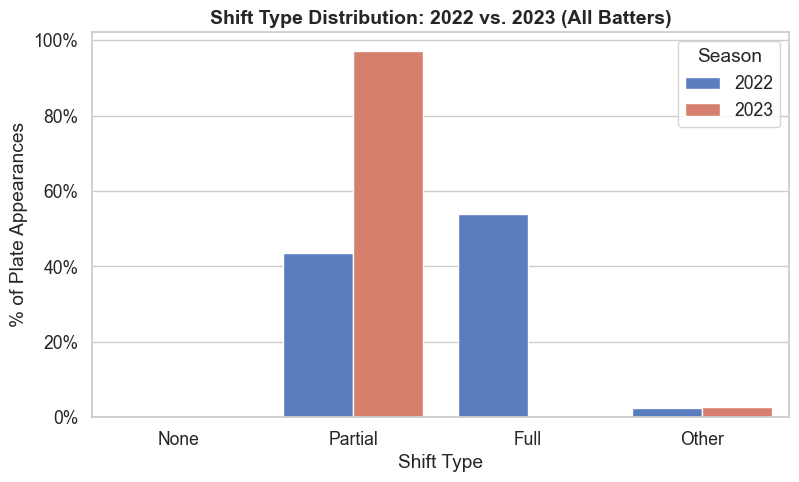

  Saved: ./figures/1a_shift_distribution_overall.png


In [12]:
shift_order = ["None", "Partial", "Full", "Other"]
 
# 1A: Overall shift distribution by year
shift_dist = (
    raw_data.groupby(["Season", "ShiftType"])
    .size()
    .reset_index(name="count")
)
shift_dist["pct"] = shift_dist.groupby("Season")["count"].transform(
    lambda x: x / x.sum() * 100
)
 
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=shift_dist,
    x="ShiftType", y="pct", hue="Season",
    order=shift_order, palette=YEAR_PALETTE, ax=ax
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Shift Type Distribution: 2022 vs. 2023 (All Batters)", fontsize=14, weight="bold")
ax.set_xlabel("Shift Type")
ax.set_ylabel("% of Plate Appearances")
ax.legend(title="Season")
plt.show()
savefig(fig, "1a_shift_distribution_overall.png")


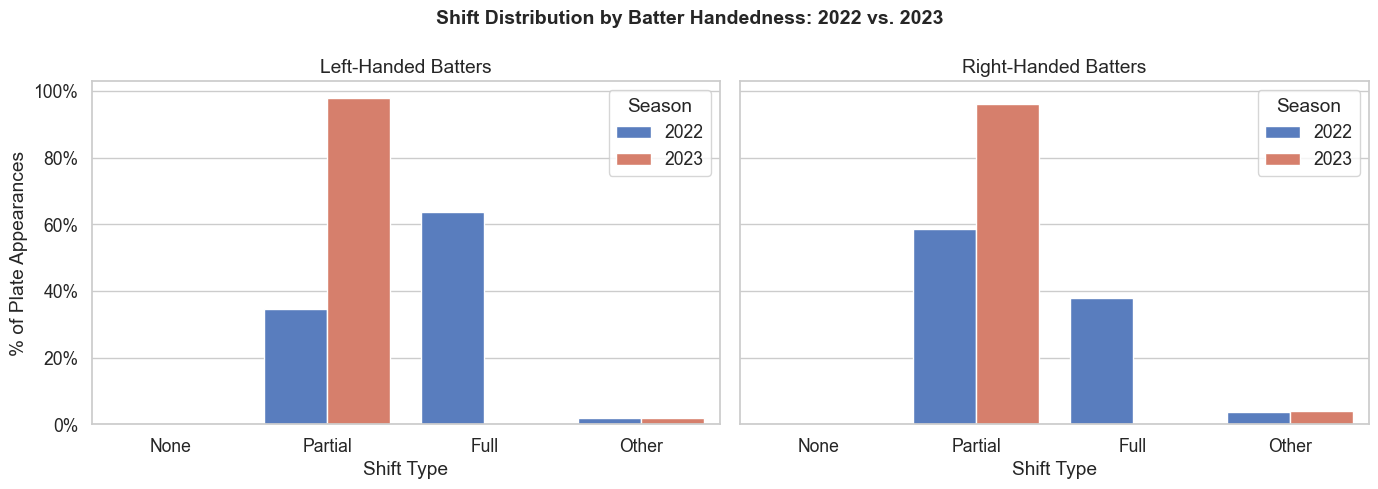

  Saved: ./figures/1b_shift_distribution_by_handedness.png


In [13]:
# 1B: Shift distribution split by batter handedness
shift_hand = (
    raw_data.groupby(["Season", "BatSide", "ShiftType"])
    .size()
    .reset_index(name="count")
)
shift_hand["pct"] = shift_hand.groupby(["Season", "BatSide"])["count"].transform(
    lambda x: x / x.sum() * 100
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, side in zip(axes, ["L", "R"]):
    sub = shift_hand[shift_hand["BatSide"] == side]
    sns.barplot(
        data=sub, x="ShiftType", y="pct", hue="Season",
        order=shift_order, palette=YEAR_PALETTE, ax=ax
    )
    ax.set_title(f"{'Left' if side == 'L' else 'Right'}-Handed Batters")
    ax.set_xlabel("Shift Type")
    ax.set_ylabel("% of Plate Appearances" if side == "L" else "")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Season")
 
fig.suptitle("Shift Distribution by Batter Handedness: 2022 vs. 2023", fontsize=14, weight="bold")
fig.tight_layout()
plt.show()
savefig(fig, "1b_shift_distribution_by_handedness.png")

In [14]:
# 1C: Full shift rate change summary table
full_shift_summary = (
    raw_data[raw_data["ShiftType"] == "Full"]
    .groupby(["Season", "BatSide"])
    .size()
    .reset_index(name="full_shift_count")
)
total = raw_data.groupby(["Season", "BatSide"]).size().reset_index(name="total")
full_shift_summary = full_shift_summary.merge(total, on=["Season", "BatSide"])
full_shift_summary["full_shift_rate"] = (
    full_shift_summary["full_shift_count"] / full_shift_summary["total"] * 100
)
print(full_shift_summary.to_string(index=False))

 Season BatSide  full_shift_count  total  full_shift_rate
   2022       L             29150  49994        58.306997
   2022       R             10695  47005        22.752899


# Part 2: Behavior of the Corners

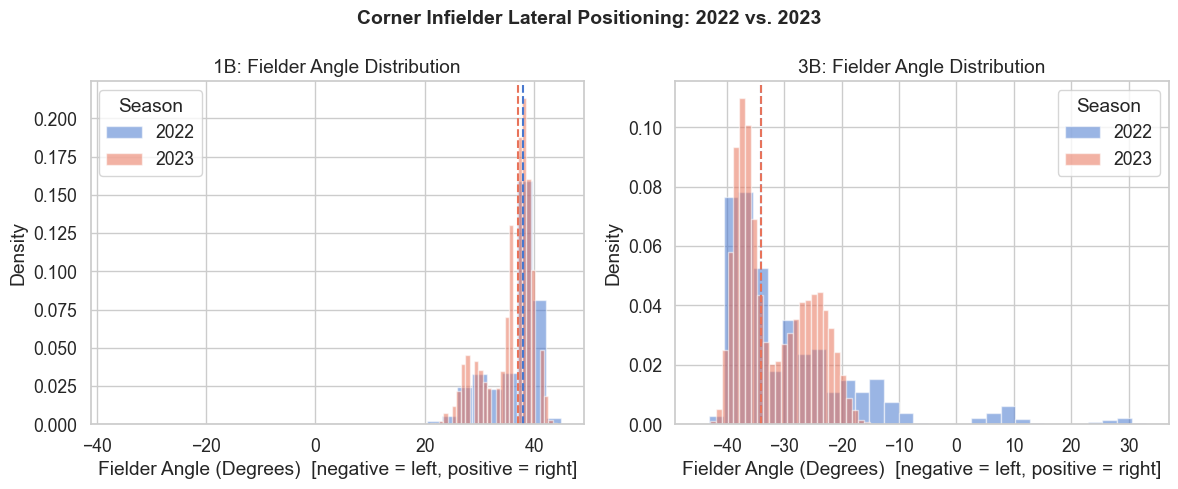

  Saved: ./figures/2a_corner_angle_distribution.png


In [15]:
corners = raw_data[raw_data["Pos"].isin(CORNER_POSITIONS)].copy()
 
# 2A: Angle distribution (lateral positioning) by position and year
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pos in zip(axes, CORNER_POSITIONS):
    sub = corners[corners["Pos"] == pos]
    for yr, color in YEAR_PALETTE.items():
        subset = sub[sub["Season"] == yr]["FielderAngle"].dropna()
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=str(yr), density=True)
        ax.axvline(subset.median(), color=color, linestyle="--", linewidth=1.5)
    pos_label = "1B" if pos == CORNER_POSITIONS[0] else "3B"
    ax.set_title(f"{pos_label}: Fielder Angle Distribution")
    ax.set_xlabel("Fielder Angle (Degrees)  [negative = left, positive = right]")
    ax.set_ylabel("Density")
    ax.legend(title="Season")
 
fig.suptitle("Corner Infielder Lateral Positioning: 2022 vs. 2023", fontsize=14, weight="bold")
fig.tight_layout()
plt.show()
savefig(fig, "2a_corner_angle_distribution.png")

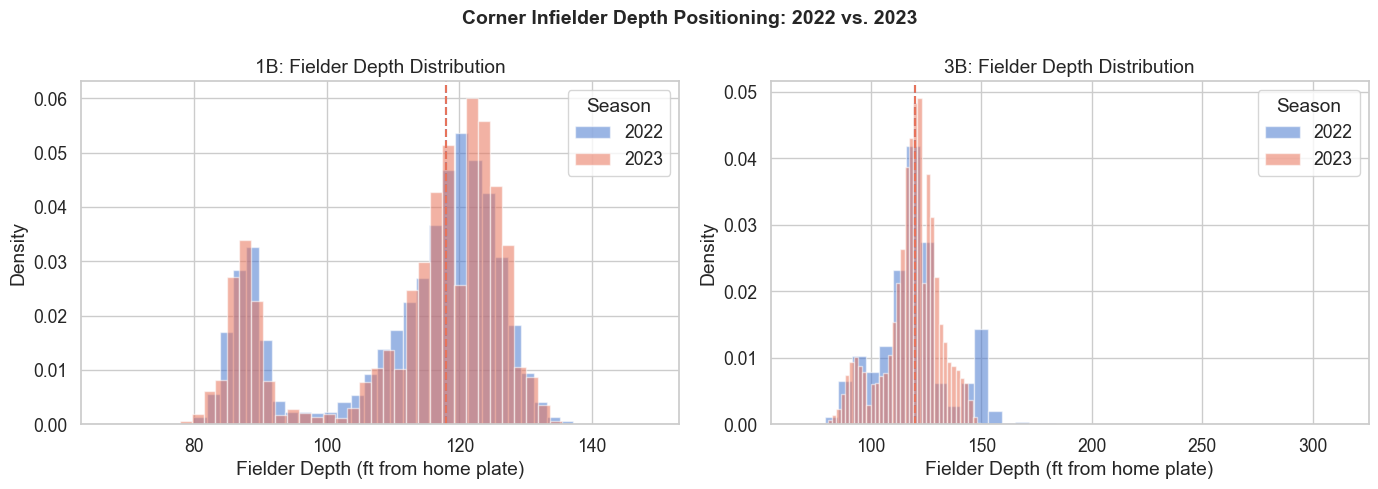

  Saved: ./figures/2b_corner_depth_distribution.png


In [16]:
# 2B: Depth distribution by position and year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pos in zip(axes, CORNER_POSITIONS):
    sub = corners[corners["Pos"] == pos]
    for yr, color in YEAR_PALETTE.items():
        subset = sub[sub["Season"] == yr]["FielderDepth"].dropna()
        ax.hist(subset, bins=40, alpha=0.55, color=color, label=str(yr), density=True)
        ax.axvline(subset.median(), color=color, linestyle="--", linewidth=1.5)
    pos_label = "1B" if pos == CORNER_POSITIONS[0] else "3B"
    ax.set_title(f"{pos_label}: Fielder Depth Distribution")
    ax.set_xlabel("Fielder Depth (ft from home plate)")
    ax.set_ylabel("Density")
    ax.legend(title="Season")
 
fig.suptitle("Corner Infielder Depth Positioning: 2022 vs. 2023", fontsize=14, weight="bold")
fig.tight_layout()
plt.show()
savefig(fig, "2b_corner_depth_distribution.png")

2C creates an HTML interactive scatter plot to view corner infielder positioning. I used the Live Server extension in VS Code to view the .html in my web browser. 

In [17]:
# 2C: Interactive 2D scatter — angle vs. depth (HTML practice, fix later)
sample = corners.sample(min(5000, len(corners)), random_state=42)
pos_labels = {CORNER_POSITIONS[0]: "1B", CORNER_POSITIONS[1]: "3B"}
sample["Position"] = sample["Pos"].map(pos_labels)
 
fig_plotly = px.scatter(
    sample, x="FielderAngle", y="FielderDepth",
    color="Season", facet_col="Position",
    color_discrete_map=YEAR_PALETTE,
    opacity=0.35,
    labels={"FielderAngle": "Angle (Degree)", "FielderDepth": "Depth (ft)"},
    title="Corner Infielder Positioning Cloud: 2022 vs. 2023"
)
fig_plotly.update_traces(marker=dict(size=4))
save_plotly(fig_plotly, "2c_positioning_scatter_interactive.html")

  Saved: ./figures/2c_positioning_scatter_interactive.html


# Part 3: Expected Out Rates

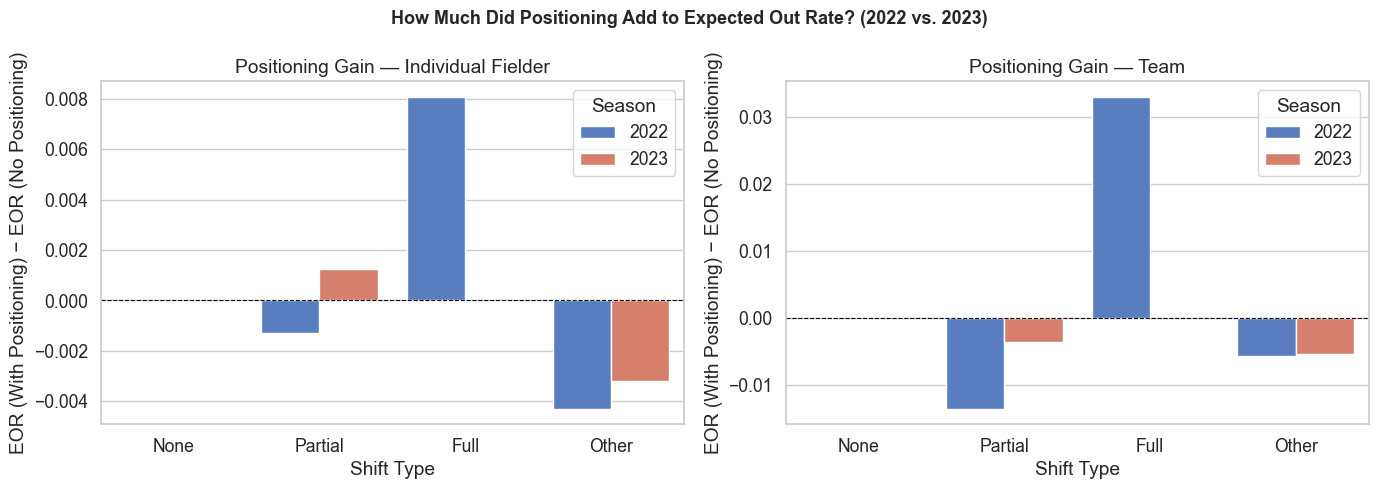

  Saved: ./figures/3a_eor_positioning_gain_by_shift.png


In [18]:
# Col creation (EOR Helpers)
raw_data["EOR_positioning_gain"] = (
    raw_data["ExpOutRate_WithPositioning"] - raw_data["ExpOutRate_NoPositioning"]
)
raw_data["EOR_positioning_gain_team"] = (
    raw_data["ExpOutRate_WithPositioning_Team"] - raw_data["ExpOutRate_NoPositioning_Team"]
)
 
# 3A: Mean positioning gain by year and shift type
eor_by_shift = (
    raw_data.groupby(["Season", "ShiftType"])[["EOR_positioning_gain", "EOR_positioning_gain_team"]]
    .mean()
    .reset_index()
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, col, label in zip(
    axes,
    ["EOR_positioning_gain", "EOR_positioning_gain_team"],
    ["Individual Fielder", "Team"]
):
    sns.barplot(
        data=eor_by_shift, x="ShiftType", y=col, hue="Season",
        order=shift_order, palette=YEAR_PALETTE, ax=ax
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Positioning Gain — {label}")
    ax.set_xlabel("Shift Type")
    ax.set_ylabel("EOR (With Positioning) − EOR (No Positioning)")
    ax.legend(title="Season")
 
fig.suptitle(
    "How Much Did Positioning Add to Expected Out Rate? (2022 vs. 2023)",
    fontsize=13, weight="bold"
)
fig.tight_layout()
plt.show()
savefig(fig, "3a_eor_positioning_gain_by_shift.png")


Expected Out Rate Summary:
 Season  ExpOutRate_NoPositioning  ExpOutRate_WithPositioning  ExpOutRate_NoPositioning_Team  ExpOutRate_WithPositioning_Team
   2022                  0.393834                    0.396712                       0.705057                         0.713463
   2023                  0.414248                    0.415178                       0.697031                         0.693767


/var/folders/qm/370cgkrn7mdcd7_q2yj7h_hw0000gn/T/ipykernel_45229/1168594348.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


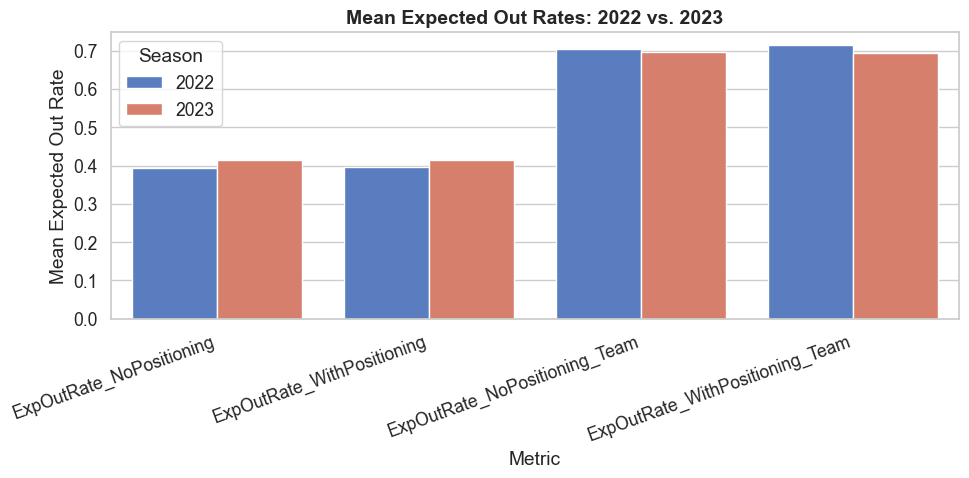

  Saved: ./figures/3b_mean_eor_comparison.png


In [19]:
# 3B: Overall mean EOR by year — no positioning vs. with positioning
eor_summary = (
    raw_data.groupby("Season")[
        ["ExpOutRate_NoPositioning", "ExpOutRate_WithPositioning",
         "ExpOutRate_NoPositioning_Team", "ExpOutRate_WithPositioning_Team"]
    ]
    .mean()
    .reset_index()
)
print("\nExpected Out Rate Summary:")
print(eor_summary.to_string(index=False))
 
eor_long = eor_summary.melt(id_vars="Season", var_name="Metric", value_name="EOR")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=eor_long, x="Metric", y="EOR", hue="Season", palette=YEAR_PALETTE, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.set_title("Mean Expected Out Rates: 2022 vs. 2023", fontsize=14, weight="bold")
ax.set_ylabel("Mean Expected Out Rate")
ax.legend(title="Season")
fig.tight_layout()
plt.show()
savefig(fig, "3b_mean_eor_comparison.png")

# Part 4: Actual vs. Expected


Out Above Expected (corner infielders):
 Season Pos     mean  count Position
   2022  1B 0.000720  11848       1B
   2022  3B 0.000142  28120       3B
   2023  1B 0.000931  11615       1B
   2023  3B 0.000035  25717       3B


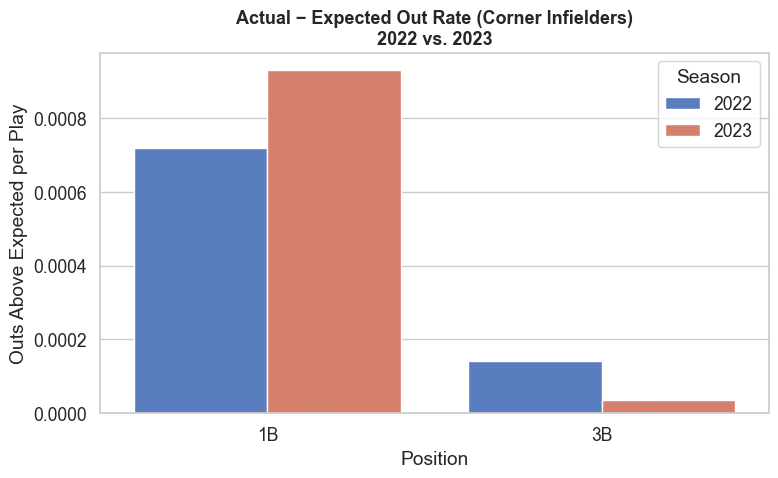

  Saved: ./figures/4a_oae_corners_by_year.png


In [20]:
corners["out_above_expected"] = (
    corners["ActualOut"] - corners["ExpOutRate_WithPositioning"]
)
 
# 4A: Mean out above expected by year and position
oae_summary = (
    corners.groupby(["Season", "Pos"])["out_above_expected"]
    .agg(["mean", "count"])
    .reset_index()
)
oae_summary["Position"] = oae_summary["Pos"].map(
    {CORNER_POSITIONS[0]: "1B", CORNER_POSITIONS[1]: "3B"}
)
print("\nOut Above Expected (corner infielders):")
print(oae_summary.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=oae_summary, x="Position", y="mean", hue="Season",
    palette=YEAR_PALETTE, ax=ax
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Actual − Expected Out Rate (Corner Infielders)\n2022 vs. 2023", fontsize=13, weight="bold")
ax.set_ylabel("Outs Above Expected per Play")
ax.set_xlabel("Position")
ax.legend(title="Season")
fig.tight_layout()
plt.show()
savefig(fig, "4a_oae_corners_by_year.png")

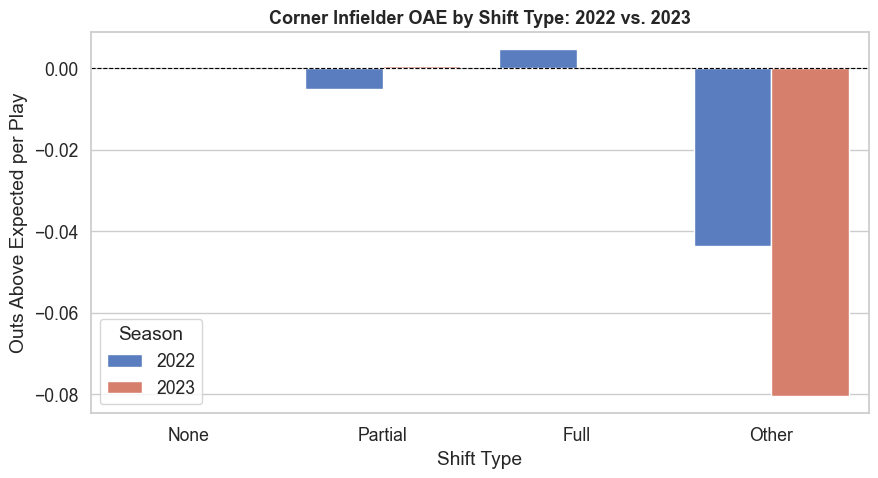

  Saved: ./figures/4b_oae_by_shift_type.png


In [21]:
# 4B: OAE by shift type — corners only
oae_shift = (
    corners.groupby(["Season", "ShiftType"])["out_above_expected"]
    .mean()
    .reset_index()
)
 
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=oae_shift, x="ShiftType", y="out_above_expected", hue="Season",
    order=shift_order, palette=YEAR_PALETTE, ax=ax
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Corner Infielder OAE by Shift Type: 2022 vs. 2023", fontsize=13, weight="bold")
ax.set_ylabel("Outs Above Expected per Play")
ax.set_xlabel("Shift Type")
ax.legend(title="Season")
fig.tight_layout()
plt.show()
savefig(fig, "4b_oae_by_shift_type.png")

# Part 5: Batter Benefit


LHB Pulled Grounder Out Rates:
 Season ShiftType  out_rate  count
   2022      Full  0.278696  22982
   2022     Other  0.523551    552
   2022   Partial  0.240713  11952
   2023     Other  0.511706    598
   2023   Partial  0.267760  32813


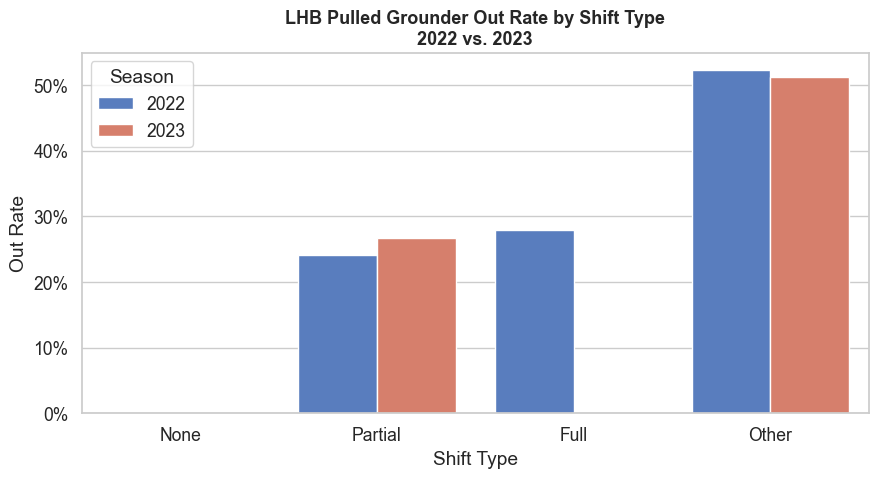

  Saved: ./figures/5a_lhb_pull_grounder_out_rate.png


In [22]:
lhb_pull = raw_data[
    (raw_data["BatSide"] == "L") &
    (raw_data["BallInPlayAngle"] > 0) &        # pulled to right side
    (raw_data["BallInPlayType"] == "Grounder")  # grounders most affected by shift
].copy()
 
# 5A: Out rate on pulled grounders — LHB by year
out_rate_lhb = (
    lhb_pull.groupby(["Season", "ShiftType"])["ActualOut"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "out_rate"})
)
print("\nLHB Pulled Grounder Out Rates:")
print(out_rate_lhb.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=out_rate_lhb, x="ShiftType", y="out_rate", hue="Season",
    order=shift_order, palette=YEAR_PALETTE, ax=ax
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title(
    "LHB Pulled Grounder Out Rate by Shift Type\n2022 vs. 2023",
    fontsize=13, weight="bold"
)
ax.set_ylabel("Out Rate")
ax.set_xlabel("Shift Type")
ax.legend(title="Season")
fig.tight_layout()
plt.show()
savefig(fig, "5a_lhb_pull_grounder_out_rate.png")

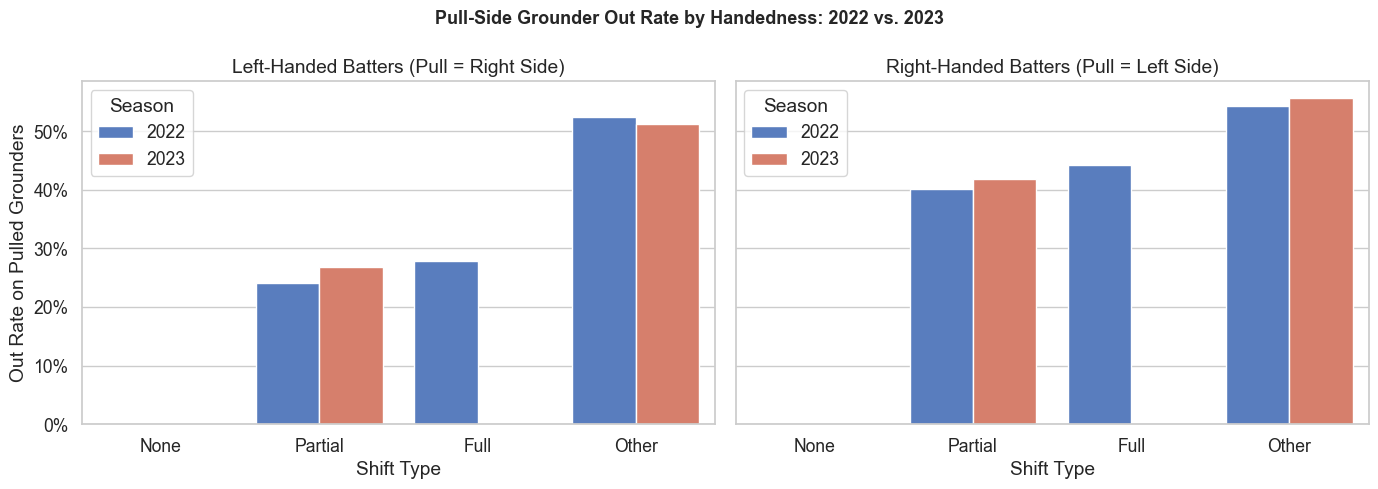

  Saved: ./figures/5b_pull_grounder_out_rate_by_handedness.png


In [23]:
# 5B: Same view for RHB pull side (negative angle = toward 3B)
rhb_pull = raw_data[
    (raw_data["BatSide"] == "R") &
    (raw_data["BallInPlayAngle"] < 0) &
    (raw_data["BallInPlayType"] == "Grounder")
].copy()
 
out_rate_rhb = (
    rhb_pull.groupby(["Season", "ShiftType"])["ActualOut"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "out_rate"})
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, data, title in zip(
    axes,
    [out_rate_lhb, out_rate_rhb],
    ["Left-Handed Batters (Pull = Right Side)", "Right-Handed Batters (Pull = Left Side)"]
):
    sns.barplot(
        data=data, x="ShiftType", y="out_rate", hue="Season",
        order=shift_order, palette=YEAR_PALETTE, ax=ax
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(title)
    ax.set_xlabel("Shift Type")
    ax.set_ylabel("Out Rate on Pulled Grounders")
    ax.legend(title="Season")
 
fig.suptitle("Pull-Side Grounder Out Rate by Handedness: 2022 vs. 2023", fontsize=13, weight="bold")
fig.tight_layout()
plt.show()
savefig(fig, "5b_pull_grounder_out_rate_by_handedness.png")

5C creates an HTML interactive line graph to view LHB grounder out rate based on ball angle. I used the Live Server extension in VS Code to view the .html in my web browser. 

In [24]:
# 5C: Interactive LHB out rate by ball angle bucket (More HTML practice)
lhb_all_grounders = raw_data[
    (raw_data["BatSide"] == "L") &
    (raw_data["BallInPlayType"] == "Grounder")
].copy()
 
# Bin by angle into 15-degree buckets
lhb_all_grounders["angle_bucket"] = pd.cut(
    lhb_all_grounders["BallInPlayAngle"],
    bins=range(-60, 75, 15),
    right=False
).astype(str)
 
out_by_angle = (
    lhb_all_grounders.groupby(["Season", "angle_bucket"])["ActualOut"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "out_rate"})
)
out_by_angle = out_by_angle[out_by_angle["count"] >= 20]  # filter thin cells
 
fig_plotly = px.line(
    out_by_angle, x="angle_bucket", y="out_rate",
    color="Season", color_discrete_map={2022: "#4878CF", 2023: "#E8735A"},
    markers=True,
    labels={"angle_bucket": "Ball in Play Angle Bucket (°)", "out_rate": "Out Rate"},
    title="LHB Grounder Out Rate by Ball Angle: 2022 vs. 2023<br><sup>Positive angles = pulled toward 1B/right side</sup>"
)
fig_plotly.update_layout(yaxis_tickformat=".0%")
save_plotly(fig_plotly, "5c_lhb_out_rate_by_angle_interactive.html")

  Saved: ./figures/5c_lhb_out_rate_by_angle_interactive.html
